In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Input
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout

In [2]:
train_datagen = ImageDataGenerator(
    rescale = 1/255, 
    zoom_range = 0.2, 
    horizontal_flip = True, 
    shear_range =0.2
)

In [8]:
train = train_datagen.flow_from_directory(
    "D:\\AshleshaRuchika\\PGCP-AI\\NLP\\imagenet-new\\train", 
    class_mode = "categorical", 
    target_size = (64, 64)
)

Found 5000 images belonging to 10 classes.


In [9]:
train.class_indices

{'crocodile': 0,
 'fish': 1,
 'fossils': 2,
 'frog': 3,
 'insect': 4,
 'reptiles': 5,
 'scorpion': 6,
 'snake': 7,
 'spider': 8,
 'toad': 9}

## Build the model

In [10]:
model = Sequential()

model.add(Input(shape = (64,64,3)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation = 'relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation = 'relu'))
model.add(MaxPool2D(2,2))


model.add(Flatten())

model.add(Dense(32, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

In [11]:
model.compile(loss="categorical_crossentropy",optimizer = "adam", metrics=["accuracy"])

In [12]:
model.fit(train, epochs =20 , batch_size=10)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.2006 - loss: 2.1740
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.3362 - loss: 1.8768
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.3864 - loss: 1.7289
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.4300 - loss: 1.6378
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.4490 - loss: 1.5836
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - accuracy: 0.4732 - loss: 1.5238
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.4840 - loss: 1.5002
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.5170 - loss: 1.4148
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.5206 - loss: 1.3959
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.5382 - loss: 1.3592
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.5606 - loss: 1.3186
Epoch 12/20
157/157 ━━━━━━━━━━

## Predict the class of an image

In [14]:
res = dict((v,k) for k,v in train.class_indices.items())

In [15]:
res

{0: 'crocodile',
 1: 'fish',
 2: 'fossils',
 3: 'frog',
 4: 'insect',
 5: 'reptiles',
 6: 'scorpion',
 7: 'snake',
 8: 'spider',
 9: 'toad'}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


'spider'

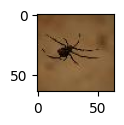

In [17]:
img=plt.imread("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\imagenet-new\\val\\images\\val_192.JPEG")
plt.figure(figsize=(1,1))
plt.imshow(img)
img=img.reshape(1,64,64,3)
pred=model.predict(img)
res[pred.argmax()]